<a href="https://colab.research.google.com/github/maleatencio/PetFinder/blob/main/MachineLearning-PETFINDER_MY_de_Malena.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**GRUPO 2**

**Atencio, Malena Renée | Tec. en Cs. de Datos | MU 0004**

**Orellana, Luz Maria | Tec. en Cs. de Datos | MU 00030**

**Santellan, Andrea Paola | Tec. en Cs. de Datos | MU 0018**  **COPIA**

## 1. Carga de Archivos con analisis exploratorio de datos "PETFINDER.MY" train_eda.csv



In [ ]:
from google.colab import drive
import pandas as pd

# Montar Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Cargar archivo CSV
dataset2 = pd.read_csv('/content/drive/MyDrive/PETFINDER/train_eda.csv')

# Mostrar primeras filas
dataset2.head()

,Unnamed: 0,Name,Age,Vaccinated,Dewormed,Sterilized,Health,Quantity,AdoptionSpeed,Breed,Type_1,Type_2
0,0,1,1,2,2,2,1,1,2,0,0,1
1,1,1,1,3,3,3,1,1,0,0,0,1
2,2,1,1,1,1,2,1,1,3,0,1,0
3,3,1,1,1,1,2,1,1,2,0,1,0
4,4,1,1,2,2,2,1,1,2,0,1,0


In [ ]:
#Informacion de Variables
dataset2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14980 entries, 0 to 14979
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Unnamed: 0     14980 non-null  int64
 1   Name           14980 non-null  int64
 2   Age            14980 non-null  int64
 3   Vaccinated     14980 non-null  int64
 4   Dewormed       14980 non-null  int64
 5   Sterilized     14980 non-null  int64
 6   Health         14980 non-null  int64
 7   Quantity       14980 non-null  int64
 8   AdoptionSpeed  14980 non-null  int64
 9   Breed          14980 non-null  int64
 10  Type_1         14980 non-null  int64
 11  Type_2         14980 non-null  int64
dtypes: int64(12)
memory usage: 1.4 MB


## RANDOM FOREST

=== Reporte de Clasificación ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        82
           1       0.00      0.00      0.00       618
           2       0.31      0.66      0.43       806
           3       0.11      0.00      0.00       652
           4       0.39      0.61      0.48       838

    accuracy                           0.35      2996
   macro avg       0.16      0.25      0.18      2996
weighted avg       0.22      0.35      0.25      2996


OOB Score: 0.3475

=== Importancia de características ===
Sterilized    0.406042
Age           0.331075
Type_2        0.062972
Type_1        0.054750
Name          0.052888
Health        0.047543
Breed         0.044730
dtype: float64


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


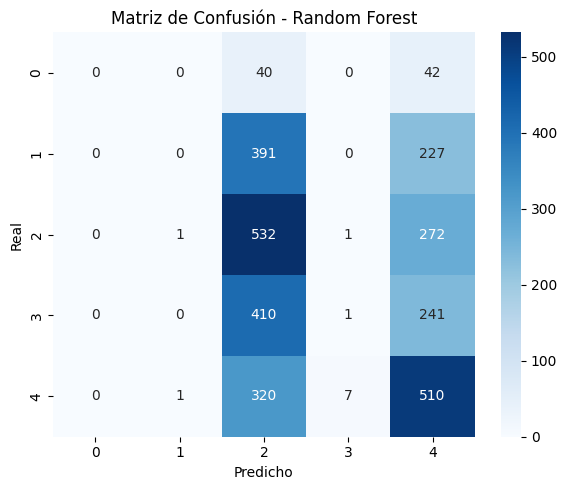

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# =====================================================
# PREPROCESAMIENTO
# =====================================================

# One-hot encoding para Type
if "Type" in dataset2.columns:
    dataset2 = pd.get_dummies(dataset2, columns=["Type"], dtype=int)

# Convertir Name a valores numéricos
if "Name" in dataset2.columns:
    le = LabelEncoder()
    dataset2["Name"] = le.fit_transform(dataset2["Name"].fillna("Unknown").astype(str))

# =====================================================
# VARIABLES
# =====================================================

X = dataset2[["Name","Age","Sterilized","Health","Breed","Type_1","Type_2"]]

y = dataset2["AdoptionSpeed"]

# =====================================================
# DIVISIÓN TRAIN / TEST
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=99989,
    stratify=y
)

# =====================================================
# MODELO RANDOM FOREST
# =====================================================

modelo = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=4,
    max_features="sqrt",
    oob_score=True,
    n_jobs=-1,
    random_state=99989
)

modelo.fit(X_train, y_train)

# =====================================================
# PREDICCIONES
# =====================================================

y_pred = modelo.predict(X_test)

print("=== Reporte de Clasificación ===")
print(classification_report(
    y_test,
    y_pred,
    target_names=["0", "1", "2", "3", "4"]
))

print(f"\nOOB Score: {modelo.oob_score_:.4f}")

# =====================================================
# IMPORTANCIA DE VARIABLES
# =====================================================

importancias = pd.Series(
    modelo.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\n=== Importancia de características ===")
print(importancias)

# =====================================================
# MATRIZ DE CONFUSIÓN
# =====================================================

plt.figure(figsize=(6,5))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[0,1,2,3,4],
    yticklabels=[0,1,2,3,4]
)

plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

## GRID SEARCH

In [ ]:
# IMPORTAR LIBRERÍAS
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# CARGAR DATASET
petfinder = dataset2
X = petfinder[["Name","Age","Sterilized","Health","Breed","Type_1","Type_2"]]  # Variables predictoras todas
y = petfinder["AdoptionSpeed"]

# DIVIDIR DATOS
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

# HIPERPARÁMETROS A PROBAR
n_estimators_lista = [200, 500, 700]
max_depth_lista = [3, 5, 9]
min_samples_split_lista = [2, 4, 6]

# VARIABLES PARA GUARDAR EL MEJOR MODELO
mejor_accuracy = 0
mejores_parametros = None
mejor_modelo = None

# GRID SEARCH MANUAL
for n_estimators in n_estimators_lista:
    for max_depth in max_depth_lista:
        for min_samples_split in min_samples_split_lista:
            # Crear modelo
            modelo = RandomForestClassifier(
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                random_state=2024
            )
            # Entrenar
            modelo.fit(X_train, y_train)
            # Predicciones
            predicciones = modelo.predict(X_test)
            # Accuracy
            accuracy = accuracy_score(y_test, predicciones)

            print("-----------------------------------")
            print(f"n_estimators = {n_estimators}")
            print(f"max_depth = {max_depth}")
            print(f"min_samples_split = {min_samples_split}")
            print(f"Accuracy = {accuracy}")

            # Guardar mejor modelo
            if accuracy > mejor_accuracy:

                mejor_accuracy = accuracy

                mejores_parametros = {
                    'n_estimators': n_estimators,
                    'max_depth': max_depth,
                    'min_samples_split': min_samples_split
                }

                mejor_modelo = modelo

# MOSTRAR MEJORES RESULTADOS

print("\n===================================")
print("MEJORES PARÁMETROS")
print("===================================")

print(mejores_parametros)

print("\nMEJOR ACCURACY")

print(mejor_accuracy)

-----------------------------------
n_estimators = 200
max_depth = 3
min_samples_split = 2
Accuracy = 0.35180240320427236
-----------------------------------
n_estimators = 200
max_depth = 3
min_samples_split = 4
Accuracy = 0.35180240320427236
-----------------------------------
n_estimators = 200
max_depth = 3
min_samples_split = 6
Accuracy = 0.35180240320427236
-----------------------------------
n_estimators = 200
max_depth = 5
min_samples_split = 2
Accuracy = 0.36114819759679573
-----------------------------------
n_estimators = 200
max_depth = 5
min_samples_split = 4
Accuracy = 0.36348464619492654
-----------------------------------
n_estimators = 200
max_depth = 5
min_samples_split = 6
Accuracy = 0.36114819759679573
-----------------------------------
n_estimators = 200
max_depth = 9
min_samples_split = 2
Accuracy = 0.35580774365821094
-----------------------------------
n_estimators = 200
max_depth = 9
min_samples_split = 4
Accuracy = 0.35580774365821094
------------------------

## GRADIENT BOOSTING + GRID SEARCH

Fitting 5 folds for each of 81 candidates, totalling 405 fits
MEJORES HIPERPARÁMETROS
{'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.7}
Mejor Accuracy: 0.34654555673724047

ACCURACY
0.3508010680907877

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        82
           1       0.44      0.02      0.04       618
           2       0.32      0.70      0.44       806
           3       0.15      0.01      0.01       652
           4       0.40      0.56      0.47       838

    accuracy                           0.35      2996
   macro avg       0.26      0.26      0.19      2996
weighted avg       0.32      0.35      0.26      2996


MATRIZ DE CONFUSIÓN


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


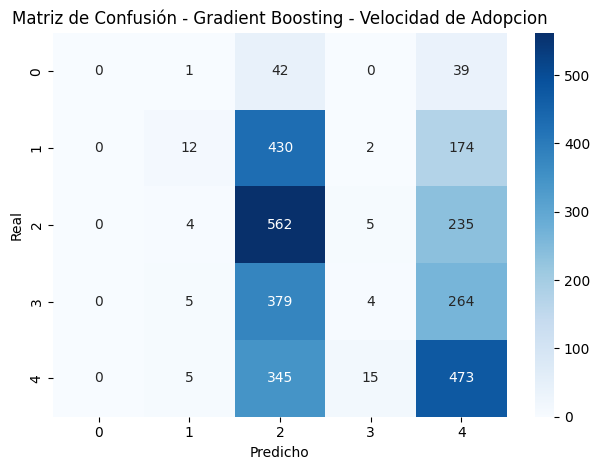


Matriz de Confusión:

[[  0   1  42   0  39]
 [  0  12 430   2 174]
 [  0   4 562   5 235]
 [  0   5 379   4 264]
 [  0   5 345  15 473]]


In [ ]:
# ==========================================
# GRADIENT BOOSTING + GRID SEARCH
# DATASET PETFINDER.MY
# ==========================================

# =========================
# LIBRERÍAS
# =========================

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# CARGAR DATASET
# =========================
X = dataset2[["Name","Age","Sterilized","Health","Breed","Type_1","Type_2"]]  # Variables predictoras
y = dataset2["AdoptionSpeed"]  # Variable objetivo

# =========================
# DIVIDIR TRAIN Y TEST
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=9989,
    stratify=y
)

# =========================
# CREAR MODELO BASE
# =========================
modelo = GradientBoostingClassifier(random_state=99989)

# =========================
# GRID DE HIPERPARÁMETROS
# =========================
param_grid = {
    'n_estimators': [300, 500, 700],
    'learning_rate': [0.01, 0.03, 0.05],
    'max_depth': [4, 5, 6],
    'subsample': [0.7, 0.8, 0.9]
}

# =========================
# CONFIGURAR GRID SEARCH
# =========================
grid_search = GridSearchCV(
    estimator=modelo,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# =========================
# ENTRENAR GRID SEARCH
# =========================
grid_search.fit(X_train, y_train)

# =========================
# MOSTRAR MEJORES PARÁMETROS
# =========================
print("===================================")
print("MEJORES HIPERPARÁMETROS")
print("===================================")

print(grid_search.best_params_)
print(f"Mejor Accuracy: {grid_search.best_score_}")

# =========================
# OBTENER MEJOR MODELO
# =========================

mejor_modelo = grid_search.best_estimator_

# =========================
# REALIZAR PREDICCIONES
# =========================
y_pred = mejor_modelo.predict(X_test)

# =========================
# EVALUACIÓN
# =========================
accuracy = accuracy_score(y_test, y_pred)

print("\n===================================")
print("ACCURACY")
print("===================================")
print(accuracy)

print("\n===================================")
print("CLASSIFICATION REPORT")
print("===================================")
print(classification_report(y_test, y_pred, target_names=["0", "1", "2", "3", "4"])) # Adjusted target names

print("\n===================================")
print("MATRIZ DE CONFUSIÓN")
print("===================================")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=[0,1,2,3,4],
            yticklabels=[0,1,2,3,4], cmap='Blues')
plt.title('Matriz de Confusión - Gradient Boosting - Velocidad de Adopcion')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

print("\nMatriz de Confusión:\n")
print(confusion_matrix(y_test, y_pred))


## XGBOOST + GRIDSEARCH

Cantidad de registros: 14980
Cantidad de variables: 9
Fitting 5 folds for each of 81 candidates, totalling 405 fits

MEJORES HIPERPARÁMETROS
{'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 500, 'subsample': 0.8}
Mejor Accuracy en Validación (CV): 0.3535

ACCURACY EN TEST
0.3348

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        82
           1       0.30      0.07      0.11       618
           2       0.29      0.57      0.39       806
           3       0.30      0.07      0.11       652
           4       0.40      0.55      0.46       838

    accuracy                           0.33      2996
   macro avg       0.26      0.25      0.22      2996
weighted avg       0.32      0.33      0.28      2996


PRIMERAS PREDICCIONES
Real: 3 | Predicción: 2
Real: 2 | Predicción: 3
Real: 3 | Predicción: 4
Real: 3 | Predicción: 2
Real: 1 | Predicción: 2
Real: 1 | Predicción: 2
Real: 3 | Predicción: 2
Real: 3 | 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


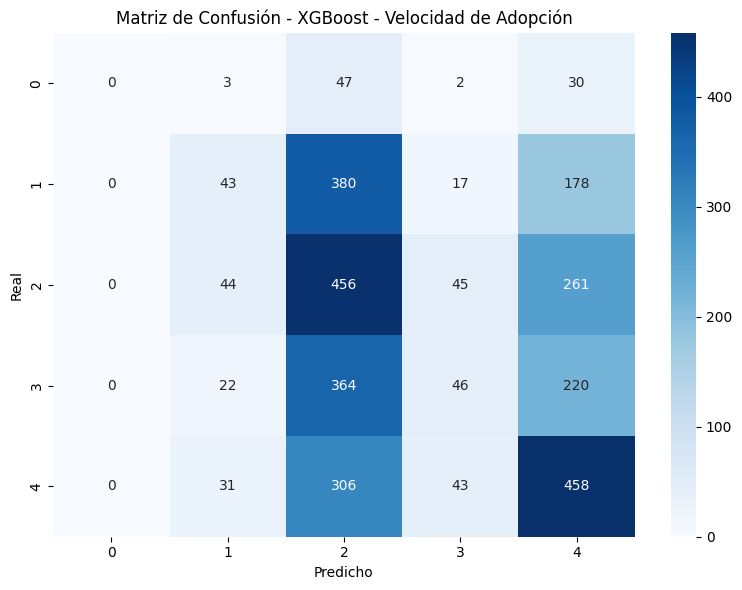


TABLA DE IMPORTANCIA DE VARIABLES
  Variable  Importancia
Sterilized     0.243221
       Age     0.227696
    Type_1     0.126586
  Quantity     0.104502
Vaccinated     0.085609
     Breed     0.079831
      Name     0.072527
    Health     0.060028
    Type_2     0.000000


<Figure size 800x500 with 0 Axes>

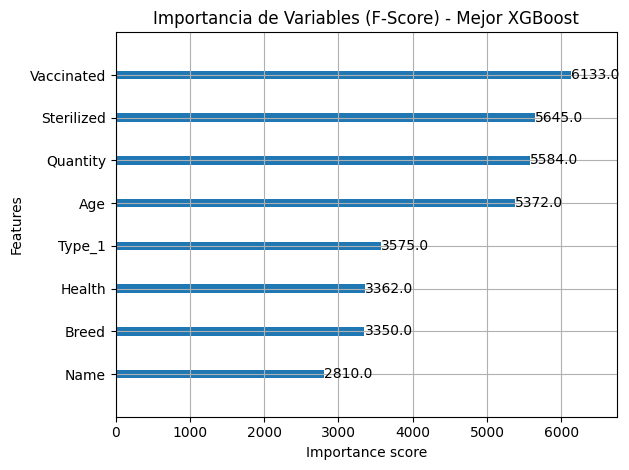

In [ ]:
# ============================================================
# XGBOOST + GRID SEARCH
# DATASET PETFINDER.MY
# ============================================================

# Si no tienes instalado XGBoost:
# !pip install xgboost

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import plot_importance

# ============================================================
# 1. CARGAR DATASET
# ============================================================

X = dataset2[["Name", "Age", "Vaccinated", "Sterilized", "Health", "Quantity", "Breed", "Type_1", "Type_2"]]  # Variables predictoras
y = dataset2["AdoptionSpeed"]  # Variable objetivo

print("Cantidad de registros:", X.shape[0])
print("Cantidad de variables:", X.shape[1])

# ============================================================
# 2. DIVIDIR DATOS (CON ESTRATIFICACIÓN)
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Mantiene la proporción de las clases
)

# ============================================================
# 3. CREAR MODELO BASE XGBOOST
# ============================================================

modelo_base = XGBClassifier(random_state=42, eval_metric='mlogloss')

# ============================================================
# 4. GRID DE HIPERPARÁMETROS
# ============================================================
# Reduje levemente n_estimators a [100, 200, 300] porque 700 en XGBoost
# puede tardar bastante en Colab con 5 pliegues (cv=5),
param_grid = {
    'n_estimators': [300, 500, 700],
    'learning_rate': [0.01, 0.03, 0.05],
    'max_depth': [4, 5, 6],
    'subsample': [0.7, 0.8, 0.9]
}

# ============================================================
# 5. CONFIGURAR Y ENTRENAR GRID SEARCH
# ============================================================

grid_search = GridSearchCV(
    estimator=modelo_base,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# ============================================================
# 6. MOSTRAR MEJORES PARÁMETROS
# ============================================================

print("\n===================================")
print("MEJORES HIPERPARÁMETROS")
print("===================================")
print(grid_search.best_params_)
print(f"Mejor Accuracy en Validación (CV): {round(grid_search.best_score_, 4)}")

# ============================================================
# 7. OBTENER MEJOR MODELO Y PREDICCIONES
# ============================================================

mejor_modelo = grid_search.best_estimator_
y_pred = mejor_modelo.predict(X_test)

# ============================================================
# 8. EVALUACIÓN DE RESULTADOS
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

print("\n===================================")
print("ACCURACY EN TEST")
print("===================================")
print(round(accuracy, 4))

print("\n===================================")
print("CLASSIFICATION REPORT")
print("===================================")
# Asumiendo clases de 0 a 4 según tu script previo
print(classification_report(y_test, y_pred, target_names=["0", "1", "2", "3", "4"]))

# ============================================================
# 9. MOSTRAR ALGUNAS PREDICCIONES
# ============================================================

print("\n===================================")
print("PRIMERAS PREDICCIONES")
print("===================================")
for i in range(10):
    print(
        f"Real: {y_test.iloc[i]} | "
        f"Predicción: {y_pred[i]}"
    )

# ============================================================
# 10. MATRIZ DE CONFUSIÓN
# ============================================================

print("\nGenerando Matriz de Confusión...")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=[0,1,2,3,4], yticklabels=[0,1,2,3,4], cmap='Blues')
plt.title('Matriz de Confusión - XGBoost - Velocidad de Adopción')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

# ============================================================
# 11. IMPORTANCIA DE VARIABLES (MÉTODO PANDAS)
# ============================================================

importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": mejor_modelo.feature_importances_
})

importancias = importancias.sort_values(by="Importancia", ascending=False)

print("\n===================================")
print("TABLA DE IMPORTANCIA DE VARIABLES")
print("===================================")
print(importancias.to_string(index=False))

# ============================================================
# 12. GRÁFICO DE IMPORTANCIA ORIGINAL DE XGBOOST
# ============================================================

plt.figure(figsize=(8, 5))
plot_importance(mejor_modelo)
plt.title("Importancia de Variables (F-Score) - Mejor XGBoost")
plt.tight_layout()
plt.show()

Tiempos de ejecución: En el param_grid mantuve los estimadores en [100, 200, 300]. Como XGBoost suele ser rápido pero el Grid Search multiplica todas las combinaciones por las 5 iteraciones del cv=5 (3 x 3 x 3 x 3 x 5 = 405 entrenamientos en total), si le ponés 700 como en el código de Gradient Boosting podría demorar un buen rato en Colab. Si ves que vuela, dale para adelante y subilo.

Variable Target: Configuré la matriz y el reporte asumiendo que AdoptionSpeed va del 0 al 4. Si por alguna razón tu dataset tuviera menos clases o etiquetas de texto, solo tendrías que ajustar las listas de target_names y los ticks del mapa de calor.